In [29]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path.cwd().resolve()
YOLOV11_DIR = (BASE_DIR / "models" / "yolov11").resolve()

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
pd.options.display.float_format = '{:.4f}'.format


In [30]:
VARIANT_ORDER = ['nano', 'small', 'medium']
VARIANT_LABELS = {'nano': 'nano (n)', 'small': 'small (s)', 'medium': 'medium (m)'}

def _parse_variant(name: str) -> str:
    suffix = name.lower().rstrip().split('-')[-1].split('v11')[-1].split('11')[-1]
    return {'n': 'nano', 's': 'small', 'm': 'medium'}.get(suffix, suffix)

# Load accuracy metrics
metrics_df = pd.read_csv(YOLOV11_DIR / "yolo_metrics.csv")
metrics_df['variant'] = metrics_df['model'].apply(_parse_variant)

# Load ONNX latency benchmark (merges all runs)
csv_files = sorted(BASE_DIR.glob("onnx_benchmark_results_*.csv"))
latency_raw = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
latency_total = (
    latency_raw[latency_raw['Phase'] == 'T_total']
    .groupby('Model')[['Median', 'P95']].mean()
    .reset_index()
)
latency_total['variant'] = latency_total['Model'].apply(_parse_variant)

# Merge into one dataframe
combined = metrics_df.merge(latency_total[['variant', 'Median', 'P95']], on='variant')
combined = combined.rename(columns={'Median': 'p50', 'P95': 'p95'})
combined['variant_label'] = combined['variant'].map(VARIANT_LABELS)
combined['variant'] = pd.Categorical(combined['variant'], categories=VARIANT_ORDER, ordered=True)
combined = combined.sort_values('variant').reset_index(drop=True)
combined


,model,map50_95,map50,map75,precision,recall,variant,p50,p95,variant_label
0,YOLOv11n,0.6953,0.8800,0.7910,0.8466,0.8025,nano,10.4726,12.6892,nano (n)
1,YOLOv11s,0.7105,0.8916,0.8002,0.8484,0.8381,small,21.3489,27.3272,small (s)
2,YOLOv11m,0.7071,0.8976,0.8110,0.8640,0.8398,medium,55.8256,67.1855,medium (m)


In [34]:
print(combined)

      model  map50_95  map50  map75  precision  recall variant     p50  \
0  YOLOv11n    0.6953 0.8800 0.7910     0.8466  0.8025    nano 10.4726   
1  YOLOv11s    0.7105 0.8916 0.8002     0.8484  0.8381   small 21.3489   
2  YOLOv11m    0.7071 0.8976 0.8110     0.8640  0.8398  medium 55.8256   

      p95 variant_label  
0 12.6892      nano (n)  
1 27.3272     small (s)  
2 67.1855    medium (m)  


# Perbandingan Latensi YOLOv11 (P50 vs P95)

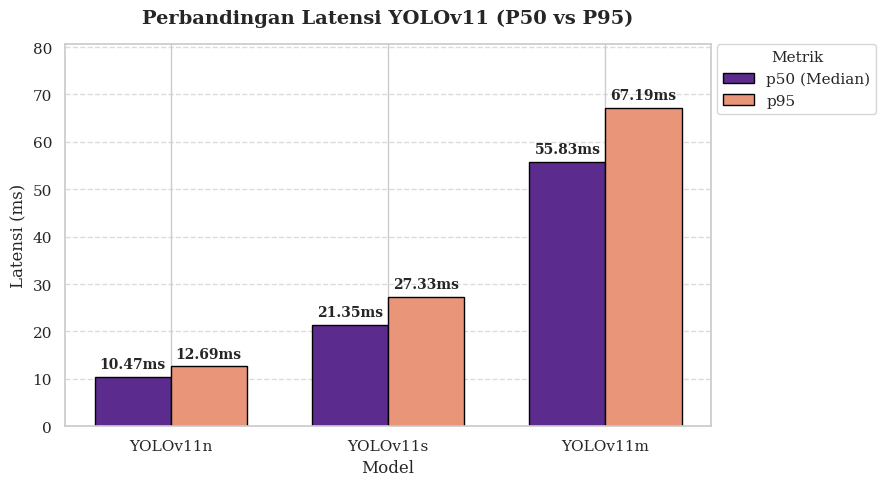

In [31]:
palette = {'p50 (Median)': '#5B2C8D', 'p95': '#E8957A'}
x = np.arange(len(VARIANT_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

for i, (label, color) in enumerate(palette.items()):
    col = 'p50' if 'p50' in label else 'p95'
    values = combined[col].values
    bars = ax.bar(x + (i - 0.5) * width, values, width, label=label, color=color,
                  edgecolor='black', linewidth=1)
    ax.bar_label(bars, labels=[f'{v:.2f}ms' for v in values],
                 padding=4, fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(combined['model'].tolist())
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Latensi (ms)', fontsize=12)
ax.set_title('Perbandingan Latensi YOLOv11 (P50 vs P95)', fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Metrik', title_fontsize=11, frameon=True, loc='upper left',
          bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(0, combined['p95'].max() * 1.2)

plt.tight_layout()
plt.show()


# Perbandingan Akurasi YOLOv11 (mAP@50 vs mAP@50-95)

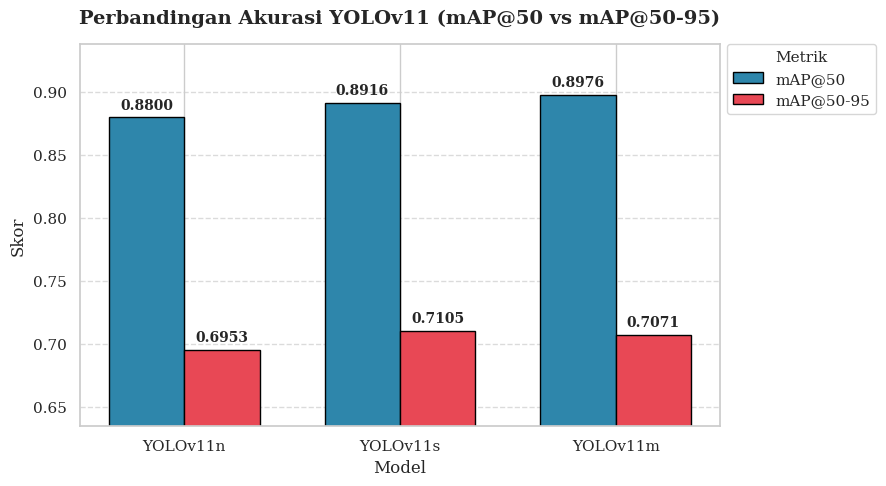

In [32]:
acc_palette = {'mAP@50': '#2E86AB', 'mAP@50-95': '#E84855'}
x = np.arange(len(combined))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

for i, (label, color) in enumerate(acc_palette.items()):
    col = 'map50' if '50-95' not in label else 'map50_95'
    values = combined[col].values
    bars = ax.bar(x + (i - 0.5) * width, values, width, label=label, color=color,
                  edgecolor='black', linewidth=1)
    ax.bar_label(bars, labels=[f'{v:.4f}' for v in values],
                 padding=4, fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(combined['model'].tolist())
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Perbandingan Akurasi YOLOv11 (mAP@50 vs mAP@50-95)', fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Metrik', title_fontsize=11, frameon=True, loc='upper left',
          bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

ymin = combined[['map50', 'map50_95']].min().min()
ymax = combined[['map50', 'map50_95']].max().max()
rng = ymax - ymin
ax.set_ylim(max(0, ymin - rng * 0.3), min(1.0, ymax + rng * 0.2))

plt.tight_layout()
plt.show()


# Pareto Frontier

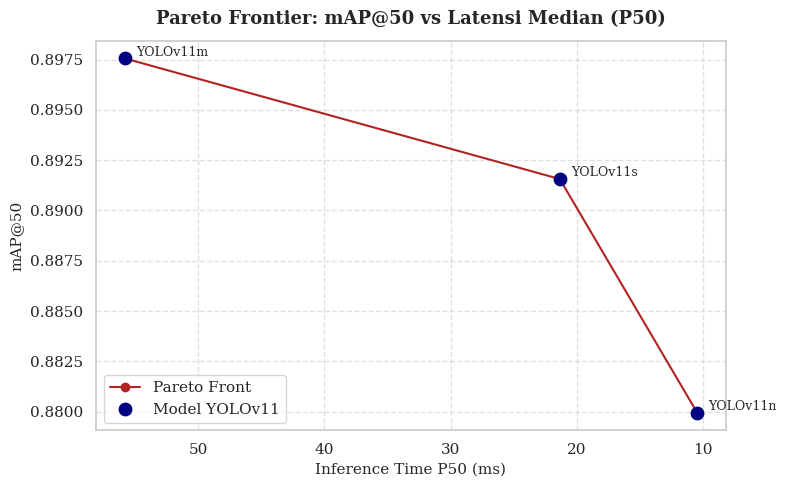

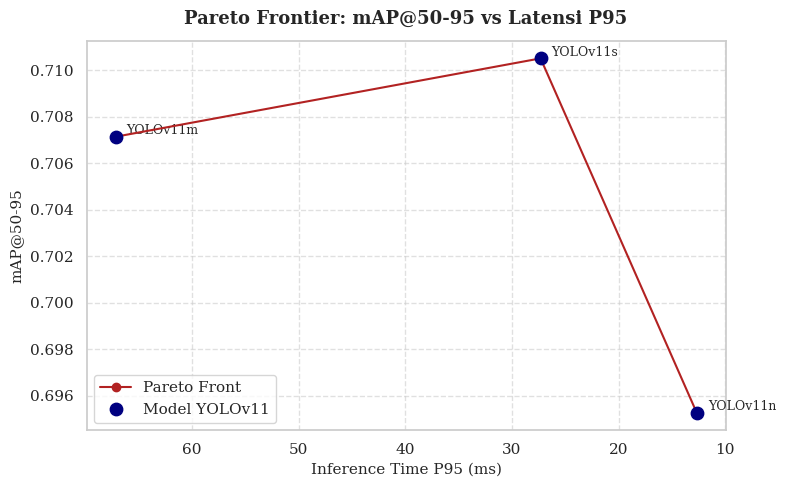

In [33]:
def plot_pareto(df: pd.DataFrame, latency_col: str, acc_col: str,
                title: str, ylabel: str, latency_label: str) -> None:
    all_sorted = df.sort_values(latency_col, ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(all_sorted[latency_col], all_sorted[acc_col],
            color='firebrick', marker='o', linewidth=1.5, label='Pareto Front', zorder=4)
    ax.scatter(df[latency_col], df[acc_col], color='navy', s=80, zorder=5, label='Model YOLOv11')

    for _, row in df.iterrows():
        ax.annotate(
            row['model'],
            (row[latency_col], row[acc_col]),
            textcoords='offset points', xytext=(8, 2), fontsize=9
        )

    ax.invert_xaxis()
    ax.set_xlabel(f'Inference Time {latency_label} (ms)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.legend(loc='lower left', frameon=True)
    ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


# mAP@50 vs Median latency (P50)
plot_pareto(combined, 'p50', 'map50',
            title='Pareto Frontier: mAP@50 vs Latensi Median (P50)',
            ylabel='mAP@50', latency_label='P50')

# mAP@50-95 vs P95 latency
plot_pareto(combined, 'p95', 'map50_95',
            title='Pareto Frontier: mAP@50-95 vs Latensi P95',
            ylabel='mAP@50-95', latency_label='P95')
